<a href="https://colab.research.google.com/github/jigme42/Biomass/blob/main/water_area_permanency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import geemap
import ee
import geopandas as gpd
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os



In [ ]:
# authentication of google earth engine
ee.Authenticate()
ee.Initialize(project='ee-jthinley') # Change the account here

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/CLA/ # Change drive name here

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
aoi_export.cpg	aoi_export.dbf	aoi_export.fix	aoi_export.prj	aoi_export.shp	aoi_export.shx


In [ ]:
roi_shp = gpd.read_file('/content/drive/MyDrive/CLA/aoi_export.shp')
roi = geemap.geopandas_to_ee(roi_shp)
Map = geemap.Map(basemap='HYBRID')
Map.addLayer(roi, {}, 'ROI')
Map.centerObject(roi, 10);
Map

Map(center=[-14.99176248805695, 133.2511005338981], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
def calculate_mndwi_l5(image): #From Landsat 5
    mndwi = image.normalizedDifference(['SR_B2', 'SR_B5']).rename('MNDWI')
    return image.addBands(mndwi)

def calculate_mndwi_l7(image): # From landsat 7
    mndwi = image.normalizedDifference(['SR_B2', 'SR_B5']).rename('MNDWI')
    return image.addBands(mndwi)


def calculate_mndwi_l8(image): # From landsat 8
    mndwi = image.normalizedDifference(['SR_B3', 'SR_B6']).rename('MNDWI')
    return image.addBands(mndwi)

def calculate_mndwi_s2(image): #From sentinel 2
    mndwi = image.normalizedDifference(['B3', 'B11']).rename('MNDWI')
    return image.addBands(mndwi)

In [ ]:
mndwi_values = []

years = list(range(1984, 2025))
threshold=0.5

def mndwi_visualization(index, years, roi, palette):
    Map = geemap.Map(basemap='HYBRID')
    Map.centerObject(roi, 10)


    for year in years:
        # Process Landsat 5 imagery for the year
        l5_collection = ee.ImageCollection("LANDSAT/LT05/C02/T1_L2") \
            .filterDate(f'{year}-01-01', f'{year}-12-31') \
            .filterBounds(roi) \
            .select('SR_B2', 'SR_B5')\
            .map(calculate_mndwi_l5)

        # Process Landsat 7 imagery for the year
        l7_collection = ee.ImageCollection("LANDSAT/LE07/C02/T2_L2") \
            .filterDate(f'{year}-01-01', f'{year}-12-31') \
            .filterBounds(roi) \
            .select('SR_B2', 'SR_B5')\
            .map(calculate_mndwi_l7)

        # Process Landsat 8 imagery for the year
        l8_collection = ee.ImageCollection("LANDSAT/LC08/C02/T2_L2") \
            .filterDate(f'{year}-01-01', f'{year}-12-31') \
            .filterBounds(roi) \
            .select('SR_B3', 'SR_B6')\
            .map(calculate_mndwi_l8)

        # Process Sentinel-2 imagery for the year
        s2_collection = ee.ImageCollection("COPERNICUS/S2_SR") \
            .filterDate(f'{year}-01-01', f'{year}-12-31') \
            .filterBounds(roi) \
            .select('B3', 'B11')\
            .map(calculate_mndwi_s2)

        # Calculate the median MNDWI for each satellite collection, if not empty
        if l5_collection.size().getInfo() > 0:
            l5_median = l5_collection.median().clip(roi).select(index)
            l5_threshold_mask = l5_median.gt(threshold)
            Map.addLayer(l5_median, palette, f"L5_{index}_{year}")
            Map.addLayer(l5_threshold_mask.updateMask(l5_threshold_mask),
                         {'palette': ['blue'], 'opacity': 0.5}, f"L5_Water_{year}")
            mndwi_l5 = l5_median.reduceRegion(ee.Reducer.mean(), roi, 30).get('MNDWI').getInfo()
        else:
            mndwi_l5 = None

        if l7_collection.size().getInfo() > 0:
            l7_median = l7_collection.median().clip(roi).select(index)
            l7_threshold_mask = l7_median.gt(threshold)
            Map.addLayer(l7_median, palette, f"L7_{index}_{year}")
            Map.addLayer(l7_threshold_mask.updateMask(l7_threshold_mask),
                         {'palette': ['blue'], 'opacity': 0.5}, f"L7_Water_{year}")
            mndwi_l7 = l7_median.reduceRegion(ee.Reducer.mean(), roi, 30).get('MNDWI').getInfo()
        else:
            mndwi_l7 = None

        if l8_collection.size().getInfo() > 0:
            l8_median = l8_collection.median().clip(roi).select(index)
            l8_threshold_mask = l8_median.gt(threshold)
            Map.addLayer(l8_median, palette, f"L8_{index}_{year}")
            Map.addLayer(l8_threshold_mask.updateMask(l8_threshold_mask),
                         {'palette': ['blue'], 'opacity': 0.5}, f"L8_Water_{year}")
            mndwi_l8 = l8_median.reduceRegion(ee.Reducer.mean(), roi, 30).get('MNDWI').getInfo()
        else:
            mndwi_l8 = None

        if s2_collection.size().getInfo() > 0:
            s2_median = s2_collection.median().clip(roi).select(index)
            s2_threshold_mask = s2_median.gt(threshold)
            Map.addLayer(s2_median, palette, f"S2_{index}_{year}")
            Map.addLayer(s2_threshold_mask.updateMask(s2_threshold_mask),
                         {'palette': ['blue'], 'opacity': 0.5}, f"S2_Water_{year}")
            mndwi_s2 = s2_median.reduceRegion(ee.Reducer.mean(), roi, 30).get('MNDWI').getInfo()
        else:
            mndwi_s2 = None

        # Store the MNDWI values for each year and satellite in the list
        mndwi_values.append({
            'Year': year,
            'L5': mndwi_l5,
            'L7': mndwi_l7,
            'L8': mndwi_l8,
            'S2': mndwi_s2
        })

    # Add a color bar for the MNDWI layer
    Map.add_colorbar(palette, label=index, layer_name=index, orientation="horizontal", transparent_bg=True)

    # Add layer control for toggling layers on/off
    Map.addLayerControl()

    # Return the map and the MNDWI values for plotting later
    return Map, mndwi_values


In [ ]:
index='MNDWI'
years=list(range(1984, 2025))
mndwi_vis = {
    'min': -1,
    'max': 1,
    'palette': ['brown', 'white', 'blue']
}
Map, mndwi_values=mndwi_visualization(index,years, roi,mndwi_vis)
Map

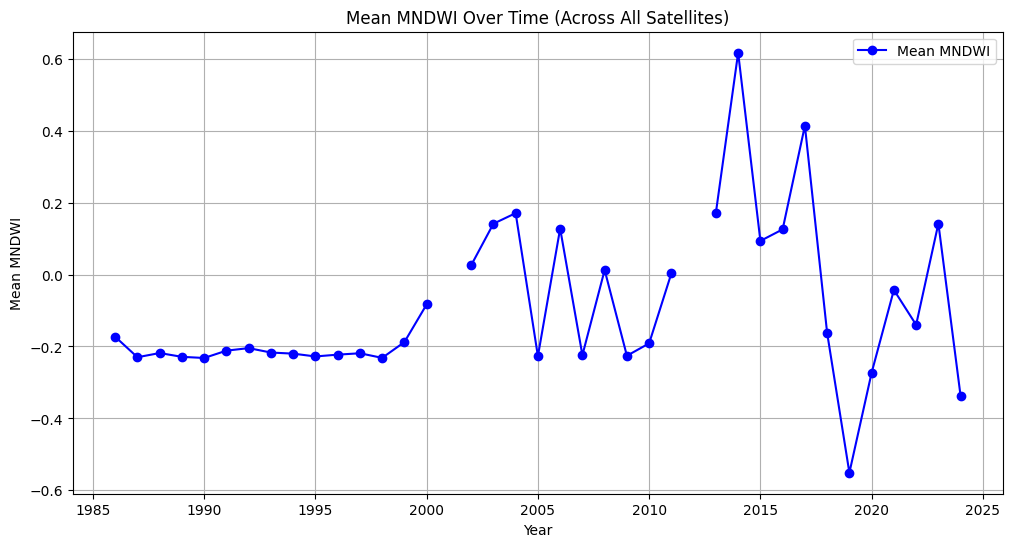

In [ ]:
mndwi_df = pd.DataFrame(mndwi_values)
mndwi_df['Mean_MNDWI'] = mndwi_df[['L5', 'L7', 'L8', 'S2']].mean(axis=1)

# Plot the single continuous line representing the mean MNDWI over the years
plt.figure(figsize=(12, 6))
plt.plot(mndwi_df['Year'], mndwi_df['Mean_MNDWI'], marker='o', linestyle='-', color='blue', label='Mean MNDWI')

# Set the plot title and labels
plt.title("Mean MNDWI Over Time (Across All Satellites)")
plt.xlabel("Year")
plt.ylabel("Mean MNDWI")
plt.legend()
plt.grid(True)
plt.show()